<a href="https://colab.research.google.com/github/mnyika-quant/xauusd-elliott-wave-backtest/blob/main/XAUUSD_Elliott_Wave_Backtest_Preferred_Count.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
# ============================================================
# XAUUSD ELLIOTT WAVE BACKTEST — PREFERRED COUNT
# ============================================================
# Strategy:   Leading Diagonal (Wave 1 Minor) +
#             ABC Zigzag Short (Wave 2 Minor)
# Timeframe:  4 Hour
# Data:       GC=F Gold Futures via yfinance
# Capital:    $100,000
# By:         Munyaradzi Nyika | Wave & Code
# Research:   waveandcode.substack.com
# Code:       github.com/mnyika-quant
# Signals:    t.me/waveandcodesignals
# ============================================================

!pip install yfinance pandas numpy matplotlib --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully')

All libraries imported successfully


In [59]:
# ============================================================
# DATA PREPARATION
#
# Source:     GC=F Gold Futures via yfinance
# Method:     Download 1H bars then resample to 4H
# Reason:     yfinance does not offer 4H directly
#             Resampling 1H to 4H gives clean 4H OHLCV bars
#
# Date range: Nov 2024 to Mar 2026
#             Covers full wave structure from diagonal start
#             at 4,655.23 through to current price action
# ============================================================

# Download 1H data
raw = yf.download(
    'GC=F',
    start='2024-11-01',
    end='2026-03-13',
    interval='1h',
    auto_adjust=True,
    progress=False
)

# Flatten multi-level columns if present
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

# Resample 1H to 4H OHLCV
gold = raw.resample('4h').agg({
    'Open':   'first',
    'High':   'max',
    'Low':    'min',
    'Close':  'last',
    'Volume': 'sum'
}).dropna()

print(f'Shape:          {gold.shape}')
print(f'Date range:     {gold.index[0]} to {gold.index[-1]}')
print(f'Price range:    {gold["Low"].min():.2f} to {gold["High"].max():.2f}')
print(f'Total 4H bars:  {len(gold)}')
print()
print(gold[['Open','High','Low','Close']].tail(5))


Shape:          (2101, 5)
Date range:     2024-11-01 04:00:00+00:00 to 2026-03-13 00:00:00+00:00
Price range:    2541.50 to 5626.80
Total 4H bars:  2101

Price                             Open         High          Low        Close
Datetime                                                                     
2026-03-12 08:00:00+00:00  5188.200195  5197.799805  5178.600098  5184.799805
2026-03-12 12:00:00+00:00  5185.000000  5192.500000  5114.600098  5138.000000
2026-03-12 16:00:00+00:00  5138.100098  5144.299805  5084.500000  5091.700195
2026-03-12 20:00:00+00:00  5092.000000  5104.399902  5058.200195  5101.500000
2026-03-13 00:00:00+00:00  5101.000000  5132.399902  5100.399902  5116.200195


In [60]:
# ============================================================
# DATA HEALTH CHECK
#
# Verify that all key wave levels fall within the
# price range of our dataset before running the backtest
# All checks must return True to proceed
# ============================================================

print('=== DATA HEALTH CHECK ===')
print()
print(f'Total 4H bars:    {len(gold)}')
print(f'Missing values:')
print(gold.isnull().sum())
print()
print('=== KEY LEVEL CHECKS ===')
print(f'  Diagonal start 4,655.23 in range:  {gold["High"].max() >= 4655.23 >= gold["Low"].min()}')
print(f'  Diagonal end   5,419.66 in range:  {gold["High"].max() >= 5419.66 >= gold["Low"].min()}')
print(f'  Wave B         5,238.78 in range:  {gold["High"].max() >= 5238.78 >= gold["Low"].min()}')
print(f'  Cond trigger   4,996.23 in range:  {gold["High"].max() >= 4996.23 >= gold["Low"].min()}')
print(f'  Target         4,815.40 in range:  {gold["High"].max() >= 4815.40 >= gold["Low"].min()}')
print(f'  Invalidation   4,655.23 in range:  {gold["High"].max() >= 4655.23 >= gold["Low"].min()}')
print()
print('All True = data is ready. Any False = adjust date range.')


=== DATA HEALTH CHECK ===

Total 4H bars:    2101
Missing values:
Price
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

=== KEY LEVEL CHECKS ===
  Diagonal start 4,655.23 in range:  True
  Diagonal end   5,419.66 in range:  True
  Wave B         5,238.78 in range:  True
  Cond trigger   4,996.23 in range:  True
  Target         4,815.40 in range:  True
  Invalidation   4,655.23 in range:  True

All True = data is ready. Any False = adjust date range.


In [61]:
# ============================================================
# RSI INDICATOR
#
# RSI (Relative Strength Index) measures the speed and
# magnitude of recent price changes to evaluate whether
# an asset is overbought or oversold
#
# Formula:
#   RSI = 100 - (100 / (1 + RS))
#   RS  = Average Gain / Average Loss over N periods
#
# Settings used:
#   RSI period:    14 bars
#   RSI MA period: 14 bar rolling mean of RSI
#
# Signal logic:
#   ENTRY — RSI crosses BELOW its MA
#     Momentum has shifted to the downside
#     Confirms our bearish ABC zigzag wave count
#
#   EXIT — RSI crosses ABOVE its MA
#     Momentum has shifted back to the upside
#     Corrective wave may be complete — close trade
# ============================================================

def calculate_rsi(series, period=14):
    """
    Calculate RSI using simple rolling average method
    period: lookback window (default 14 bars)
    """
    delta    = series.diff()
    gain     = delta.where(delta > 0, 0)
    loss     = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs       = avg_gain / avg_loss
    rsi      = 100 - (100 / (1 + rs))
    return rsi

# Calculate RSI and RSI MA
gold['RSI']    = calculate_rsi(gold['Close'], period=14)
gold['RSI_MA'] = gold['RSI'].rolling(window=14).mean()

# Detect RSI crossovers
# Cross below: RSI was above MA last bar, now below MA
gold['RSI_cross_below'] = (
    (gold['RSI'] < gold['RSI_MA']) &
    (gold['RSI'].shift(1) >= gold['RSI_MA'].shift(1))
)

# Cross above: RSI was below MA last bar, now above MA
gold['RSI_cross_above'] = (
    (gold['RSI'] > gold['RSI_MA']) &
    (gold['RSI'].shift(1) <= gold['RSI_MA'].shift(1))
)

print('RSI calculated successfully')
print()
print(gold[['Close','RSI','RSI_MA']].dropna().tail(10))


RSI calculated successfully

Price                            Close        RSI     RSI_MA
Datetime                                                    
2026-03-11 12:00:00+00:00  5173.399902  63.651172  58.964155
2026-03-11 16:00:00+00:00  5191.000000  68.991562  60.957577
2026-03-11 20:00:00+00:00  5140.000000  55.447931  61.892429
2026-03-12 00:00:00+00:00  5158.200195  51.451220  61.656609
2026-03-12 04:00:00+00:00  5188.399902  56.546821  61.410715
2026-03-12 08:00:00+00:00  5184.799805  53.264706  60.964187
2026-03-12 12:00:00+00:00  5138.000000  41.379310  59.834738
2026-03-12 16:00:00+00:00  5091.700195  36.574746  58.298425
2026-03-12 20:00:00+00:00  5101.500000  27.287854  55.161190
2026-03-13 00:00:00+00:00  5116.200195  34.025380  53.405069


In [62]:
# ============================================================
# ELLIOTT WAVE STRUCTURE — PREFERRED COUNT
#
# CONTEXT — Intermediate Degree (White Labels):
#   Wave 4 low:   4,402.38  — foundation of the move
#   Wave 1 up:    5,094.07
#   Wave 2 down:  4,655.23  — diagonal starting point
#
# LEADING DIAGONAL — Minute Degree (Blue Labels):
#   Labelled as Wave 1 of Minor Degree
#   Wave 1:  4,655.23 → 5,121.167
#   Wave 2:  5,121.167 → 4,842.60
#   Wave 3:  4,842.60 → 5,254.86
#   Wave 4:  5,254.86 → 5,094.07
#   Wave 5:  5,094.07 → 5,419.66 — Diagonal Complete
#
# ABC ZIGZAG — Minor Degree (Yellow Labels):
#   Labelled as Wave 2 of Minor Degree
#   Wave A:  5,419.66 → 4,996.28
#   Wave B:  ABC zigzag → 5,238.78
#   Wave C:  In progress → Target 4,815.40
#   Wave B completed on 10 March 2026
#   First valid entry date: 10 March 2026
#
# FIBONACCI CONFLUENCE:
#   Diagonal range:      5,419.66 - 4,655.23 = 764.43 pts
#   0.618 retracement:   4,947.53
#   0.786 retracement:   4,818.78
#   Wave C = Wave A:     4,815.40
#   Target sits just below 0.786 — strong confluence
#
# INVALIDATION: 4,655.23
#   Daily close below this level invalidates the diagonal
#
# ============================================================
# TRADE FRAMEWORK
# ============================================================
#
# ENTRY TRADES 1 & 2:
#   Trigger:  RSI crosses below MA
#             AND price is below 5,238.78 (Wave B high)
#             AND price is above 4,655.23 (invalidation)
#             AND date is on or after 10 March 2026
#             Wave B only completed on 10 March 2026
#             No valid entry exists before that date
#   Size:     1.0 lot each (2 lots total)
#   Stop:     5,248.78 (10 point buffer above Wave B)
#
# CONDITIONAL ENTRY TRADES 3 & 4:
#   Trigger:  Price breaks below 4,996.23
#             AND entry price was above 4,996.23
#   Size:     1.0 lot each (4 lots total)
#   Stop:     5,191.71
#   Action:   Move Trades 1 & 2 stops to break even
#
# EXIT:
#   Primary:  Price reaches 4,815.40 (Wave C = Wave A)
#             AND entry price was above 4,815.40
#             AND close is below entry price
#   Early:    RSI crosses above its MA
#             AND price is below entry price
#   Stop:     As defined above per trade group
#
# VALID ENTRY WINDOW:
#   From:  10 March 2026 (Wave B completion date)
#   To:    Target hit or invalidation breach
#
# SHORT TRADE LOGIC:
#   We are SHORT — we profit when price falls
#   Target is BELOW entry — price must fall to hit it
#   Stop is ABOVE entry — price must rise to hit it
#
# CAPITAL:    $100,000
# ============================================================

# Key levels
WAVE_B_HIGH         = 5238.78   # Wave B end — entry zone
STOP_INITIAL        = 5248.78   # Stop Trades 1 & 2
CONDITIONAL_TRIGGER = 4996.23   # Triggers Trades 3 & 4
STOP_TRADES_34      = 5191.71   # Stop Trades 3 & 4
TARGET              = 4815.40   # Wave C = Wave A
INVALIDATION        = 4655.23   # Diagonal invalidation
DIAGONAL_START      = 4655.23
DIAGONAL_END        = 5419.66
WAVE_A_LOW          = 4996.28
CAPITAL             = 100000

# Wave B completion date — no entries valid before this
WAVE_B_DATE = pd.Timestamp('2026-03-10', tz='UTC')

# Initialise tracking columns
gold['position']   = 0
gold['stop_level'] = np.nan

# State variables
trades_1_2_active = False
trades_3_4_active = False
break_even_moved  = False
entry_price_12    = None
total_position    = 0
trade_log         = []

# ============================================================
# BACKTEST LOOP
# Iterates through every 4H bar
# Checks entry and exit conditions on each bar
# ============================================================

for i in range(1, len(gold)):

    # Current bar values
    current_close   = gold['Close'].iloc[i]
    current_high    = gold['High'].iloc[i]
    current_low     = gold['Low'].iloc[i]
    rsi_cross_below = gold['RSI_cross_below'].iloc[i]
    rsi_cross_above = gold['RSI_cross_above'].iloc[i]
    idx             = gold.index[i]

    # ----------------------------------------------------------
    # ENTRY TRADES 1 & 2
    #
    # Five conditions must all be True:
    # 1. No active trade currently open
    # 2. Price is BELOW Wave B high 5,238.78 — structural
    # 3. Price is ABOVE invalidation 4,655.23 — valid zone
    # 4. RSI crosses below its MA — momentum confirmation
    # 5. Date is on or after 10 March 2026
    #    Wave B only completed on this date
    #    No structurally valid entry exists before it
    # ----------------------------------------------------------
    if (not trades_1_2_active
            and current_close < WAVE_B_HIGH
            and current_close > INVALIDATION
            and rsi_cross_below
            and idx >= WAVE_B_DATE):

        trades_1_2_active = True
        entry_price_12    = current_close
        total_position    = 2
        gold.loc[idx, 'position']   = -total_position
        gold.loc[idx, 'stop_level'] = STOP_INITIAL

        trade_log.append({
            'Event': 'ENTRY — Trades 1 & 2',
            'Date':  idx,
            'Price': round(current_close, 2),
            'Lots':  2,
            'Stop':  STOP_INITIAL
        })

    # ----------------------------------------------------------
    # CONDITIONAL ENTRY TRADES 3 & 4
    #
    # Four conditions must all be True:
    # 1. Trades 1 & 2 are already active
    # 2. Trades 3 & 4 not yet triggered
    # 3. Price breaks below 4,996.23 — confirms Wave C
    # 4. Entry price was ABOVE 4,996.23
    #    Prevents false triggers when entry was already
    #    below the conditional level
    #
    # When triggered:
    # — Adds 2 more lots for total of 4
    # — Trades 1 & 2 stops moved to break even
    # ----------------------------------------------------------
    elif (trades_1_2_active
              and not trades_3_4_active
              and current_close < CONDITIONAL_TRIGGER
              and entry_price_12 > CONDITIONAL_TRIGGER):

        trades_3_4_active = True
        break_even_moved  = True
        total_position    = 4
        gold.loc[idx, 'position']   = -total_position
        gold.loc[idx, 'stop_level'] = STOP_TRADES_34

        trade_log.append({
            'Event': 'ENTRY — Trades 3 & 4  |  Trades 1 & 2 → BREAK EVEN',
            'Date':  idx,
            'Price': round(current_close, 2),
            'Lots':  4,
            'Stop':  STOP_TRADES_34
        })

    # ----------------------------------------------------------
    # EXIT CONDITIONS
    # Checked every bar while any trades are active
    # Priority order: Target → RSI exit → Stop
    # ----------------------------------------------------------
    if trades_1_2_active:

        # --------------------------------------------------
        # EXIT 1 — TARGET HIT
        # Wave C equals Wave A at 4,815.40
        #
        # Three conditions:
        # 1. Current low touches or goes below target
        # 2. Current close is below entry price
        #    confirms genuine downward movement
        # 3. Entry price was above the target
        #    prevents false trigger when entered below target
        # --------------------------------------------------
        if (current_low <= TARGET
                and current_close < entry_price_12
                and entry_price_12 > TARGET):

            gold.loc[idx, 'position'] = 0
            trade_log.append({
                'Event': 'EXIT — TARGET HIT 4,815.40',
                'Date':  idx,
                'Price': TARGET,
                'Lots':  total_position,
                'Stop':  None
            })
            trades_1_2_active = trades_3_4_active = False
            total_position    = 0

        # --------------------------------------------------
        # EXIT 2 — RSI CROSSED ABOVE MA
        # Momentum has shifted back to the upside
        # Corrective wave may be complete
        #
        # Two conditions:
        # 1. RSI crosses above its MA
        # 2. Price is below entry — confirms we are in
        #    a genuine short move before exiting
        # --------------------------------------------------
        elif (rsi_cross_above
                  and current_close < entry_price_12):

            gold.loc[idx, 'position'] = 0
            trade_log.append({
                'Event': 'EXIT — RSI crossed above MA',
                'Date':  idx,
                'Price': round(current_close, 2),
                'Lots':  total_position,
                'Stop':  None
            })
            trades_1_2_active = trades_3_4_active = False
            total_position    = 0

        # --------------------------------------------------
        # EXIT 3 — STOP HIT with Trades 3 & 4 active
        # Price rises back above 5,191.71
        # All 4 lots closed at stop level
        # --------------------------------------------------
        elif (trades_3_4_active
                  and current_high >= STOP_TRADES_34):

            gold.loc[idx, 'position'] = 0
            trade_log.append({
                'Event': 'EXIT — STOP HIT 5,191.71',
                'Date':  idx,
                'Price': STOP_TRADES_34,
                'Lots':  total_position,
                'Stop':  None
            })
            trades_1_2_active = trades_3_4_active = False
            total_position    = 0

        # --------------------------------------------------
        # EXIT 4 — STOP HIT with only Trades 1 & 2 active
        # Price rises back above 5,248.78
        # Initial 2 lots closed at stop level
        # --------------------------------------------------
        elif (not trades_3_4_active
                  and current_high >= STOP_INITIAL):

            gold.loc[idx, 'position'] = 0
            trade_log.append({
                'Event': 'EXIT — STOP HIT 5,248.78',
                'Date':  idx,
                'Price': STOP_INITIAL,
                'Lots':  total_position,
                'Stop':  None
            })
            trades_1_2_active = False
            total_position    = 0

        # --------------------------------------------------
        # NO EXIT CONDITION MET — hold position
        # --------------------------------------------------
        else:
            gold.loc[idx, 'position'] = -total_position

# ============================================================
# TRADE LOG SUMMARY
# ============================================================
print('=== TRADE LOG ===')
print()
trade_df = pd.DataFrame(trade_log)
if len(trade_df) > 0:
    print(f'Total trade events:  {len(trade_df)}')
    print()
    print('Event summary:')
    print(trade_df['Event'].value_counts())
    print()
    print('First trade:')
    print(trade_df.head(2).to_string(index=False))
    print()
    print('Last trade:')
    print(trade_df.tail(2).to_string(index=False))
    print()
    print(f'Date range of trades:')
    print(f'  First: {trade_df["Date"].iloc[0]}')
    print(f'  Last:  {trade_df["Date"].iloc[-1]}')
else:
    print('No trades fired — entry conditions not met in dataset')

# Save to CSV
trade_df.to_csv('trade_log.csv', index=False)
print()
print('Trade log saved as trade_log.csv')


=== TRADE LOG ===

Total trade events:  1

Event summary:
Event
ENTRY — Trades 1 & 2    1
Name: count, dtype: int64

First trade:
               Event                      Date  Price  Lots    Stop
ENTRY — Trades 1 & 2 2026-03-11 20:00:00+00:00 5140.0     2 5248.78

Last trade:
               Event                      Date  Price  Lots    Stop
ENTRY — Trades 1 & 2 2026-03-11 20:00:00+00:00 5140.0     2 5248.78

Date range of trades:
  First: 2026-03-11 20:00:00+00:00
  Last:  2026-03-11 20:00:00+00:00

Trade log saved as trade_log.csv


In [63]:
# ============================================================
# PERFORMANCE METRICS
#
# LOG RETURNS
#   log_return = ln(Price_t / Price_t-1)
#   More accurate than simple returns for compounding
#
# STRATEGY RETURNS
#   strategy_return = position(t-1) * log_return * -1
#   position(t-1) — use prior bar to avoid lookahead bias
#   multiply by -1 — we are SHORT so gains come from drops
#
# SHARPE RATIO
#   Sharpe = (Mean Return / Std Return) * sqrt(bars per year)
#   4H bars per year = 6 bars per day * 252 days = 1,512
#   Above 1.0 = good | Above 2.0 = excellent
#
# MAX DRAWDOWN
#   Largest peak to trough decline in equity curve
#   Measures worst case loss from any high point
#
# WIN RATE
#   Percentage of active bars with positive return
#   50% or above on a short strategy in a bull market
#   is a strong result
# ============================================================

# Calculate returns
gold['log_return']          = np.log(gold['Close'] / gold['Close'].shift(1))
gold['strategy_return']     = gold['position'].shift(1) * gold['log_return'] * -1
gold['cumulative_market']   = gold['log_return'].cumsum().apply(np.exp)
gold['cumulative_strategy'] = gold['strategy_return'].cumsum().apply(np.exp)

# Isolate return series
strategy_returns = gold['strategy_return'].dropna()
market_returns   = gold['log_return'].dropna()

# 4H bars per year
bars_per_year = 6 * 252

# Sharpe ratios
sharpe_strategy = (
    (strategy_returns.mean() / strategy_returns.std())
    * np.sqrt(bars_per_year)
    if strategy_returns.std() != 0 else 0
)
sharpe_market = (
    (market_returns.mean() / market_returns.std())
    * np.sqrt(bars_per_year)
    if market_returns.std() != 0 else 0
)

# Max drawdown
rolling_max  = gold['cumulative_strategy'].cummax()
drawdown     = (gold['cumulative_strategy'] - rolling_max) / rolling_max
max_drawdown = drawdown.min()

# Win rate
active_bars = strategy_returns[strategy_returns != 0]
win_rate    = (
    (active_bars > 0).sum() / len(active_bars)
    if len(active_bars) > 0 else 0
)

# Total returns
strategy_total = (gold['cumulative_strategy'].iloc[-1] - 1) * 100
market_total   = (gold['cumulative_market'].iloc[-1] - 1) * 100

# Print results
print('=' * 52)
print('      XAUUSD BACKTEST — PERFORMANCE METRICS')
print('=' * 52)
print(f'  Strategy Return:     {strategy_total:>10.2f}%')
print(f'  Market Return:       {market_total:>10.2f}%')
print(f'  Outperformance:      {strategy_total - market_total:>10.2f}%')
print(f'  Strategy Sharpe:     {sharpe_strategy:>10.2f}')
print(f'  Market Sharpe:       {sharpe_market:>10.2f}')
print(f'  Max Drawdown:        {max_drawdown * 100:>10.2f}%')
print(f'  Win Rate:            {win_rate * 100:>10.2f}%')
print('=' * 52)
print()
print('NOTE: Market return reflects Gold bull run.')
print('This is a SHORT strategy targeting one specific')
print('corrective setup. The relevant measure is risk')
print('management quality and directional accuracy.')


      XAUUSD BACKTEST — PERFORMANCE METRICS
  Strategy Return:          -0.92%
  Market Return:            85.40%
  Outperformance:          -86.33%
  Strategy Sharpe:          -0.26
  Market Sharpe:             1.98
  Max Drawdown:             -3.69%
  Win Rate:                 57.14%

NOTE: Market return reflects Gold bull run.
This is a SHORT strategy targeting one specific
corrective setup. The relevant measure is risk
management quality and directional accuracy.


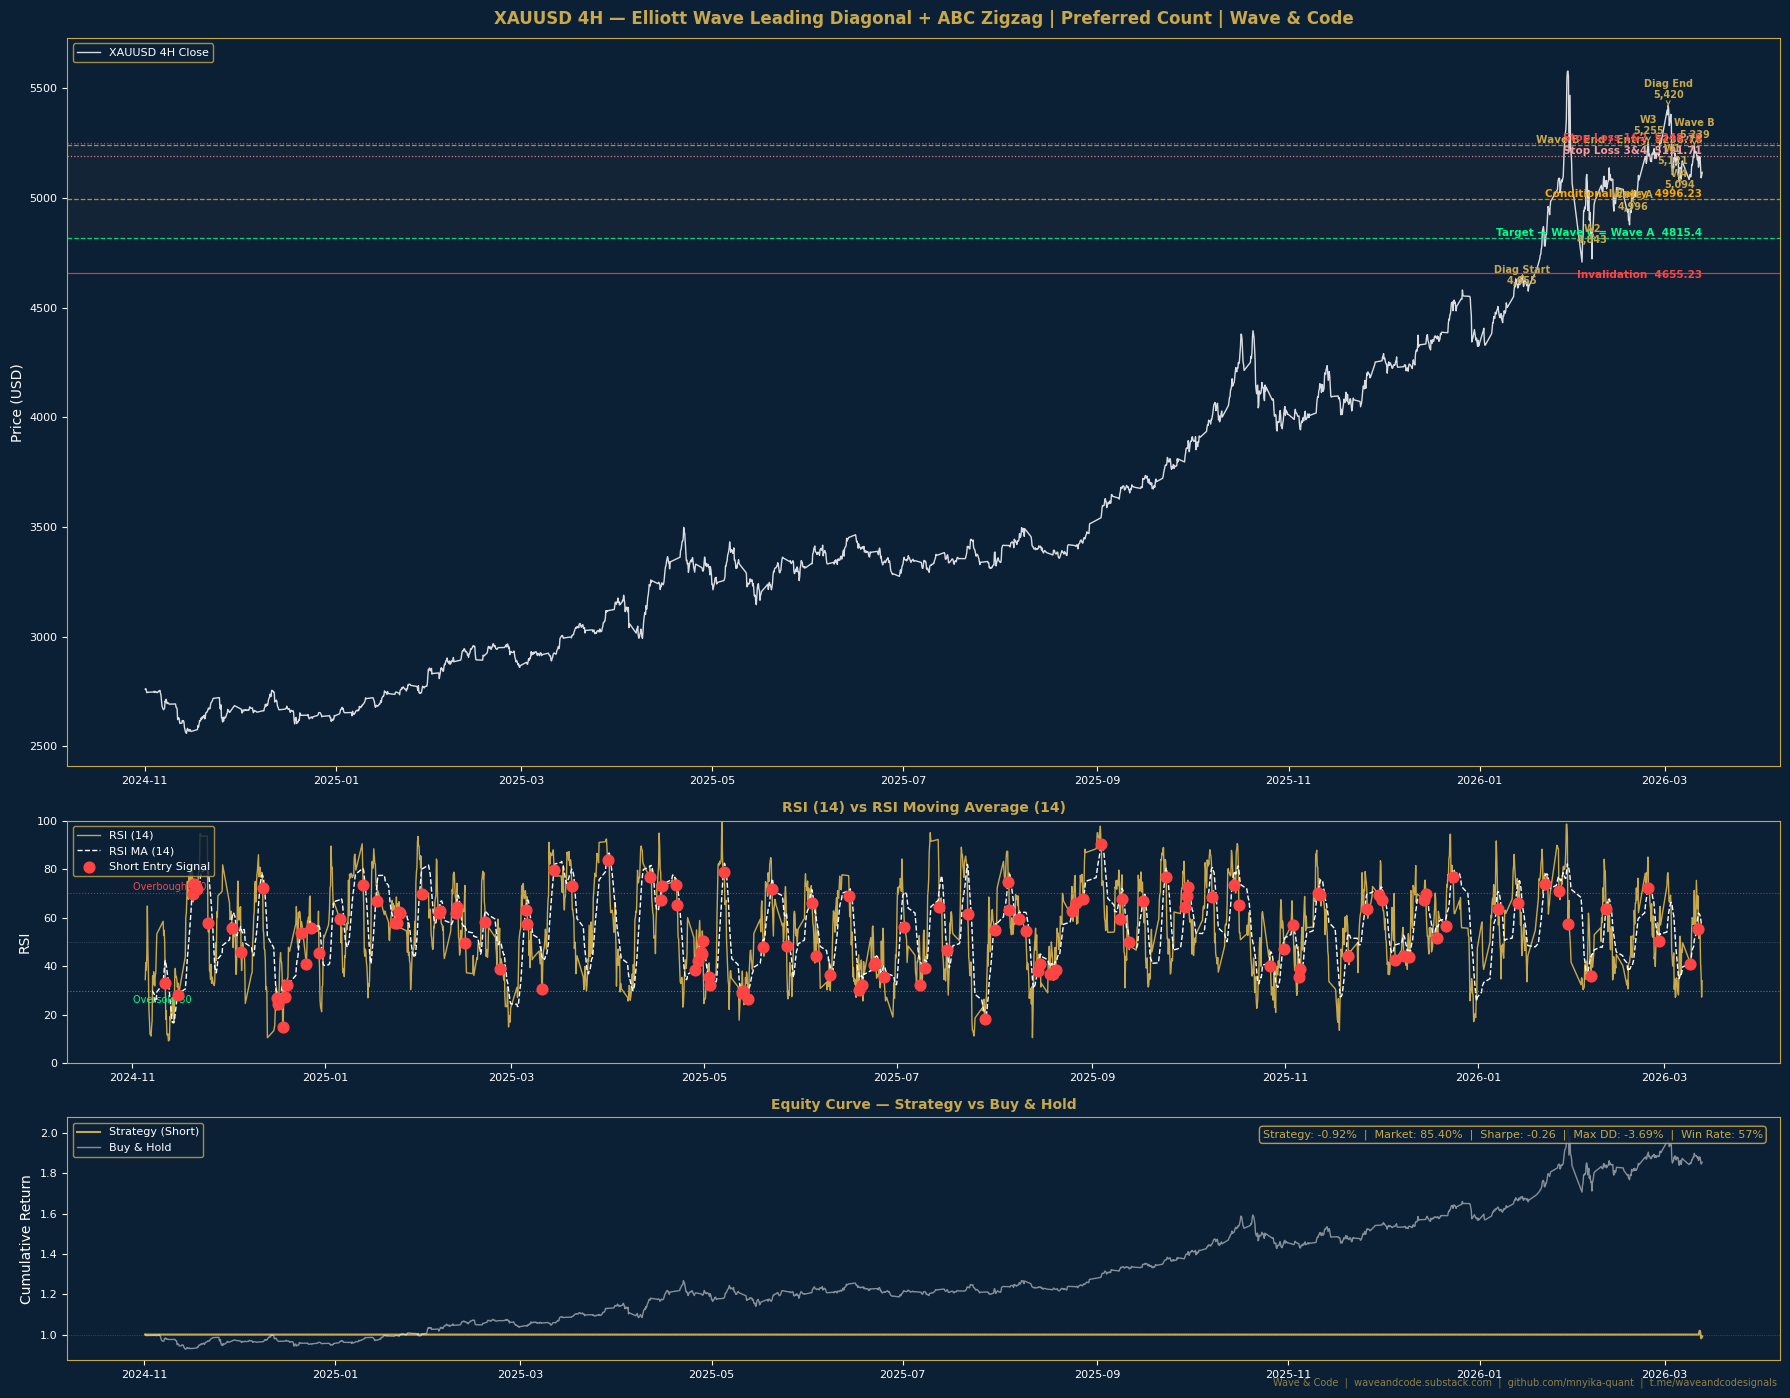

Chart saved as xauusd_elliott_wave_backtest.png


In [64]:
# ============================================================
# CHART — THREE PANELS
#
# Panel 1 — Price chart with:
#   Wave annotations at each key level
#   Horizontal lines for all trade levels
#   Shaded trade zone between entry and target
#
# Panel 2 — RSI with:
#   RSI line and RSI MA line
#   Overbought and oversold reference lines
#   Red dots marking short entry signals
#
# Panel 3 — Equity curve with:
#   Strategy cumulative return vs buy and hold
#   Performance summary box
# ============================================================

NAVY   = '#0B1F35'
GOLD_C = '#C9A84C'
WHITE  = '#FFFFFF'
GREEN  = '#00FF88'
RED    = '#FF4444'
ORANGE = '#FFA500'

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(18, 14),
    gridspec_kw={'height_ratios': [3, 1, 1]}
)
fig.patch.set_facecolor(NAVY)

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor(NAVY)
    ax.tick_params(colors=WHITE, labelsize=8)
    ax.yaxis.label.set_color(WHITE)
    ax.xaxis.label.set_color(WHITE)
    ax.title.set_color(GOLD_C)
    for spine in ax.spines.values():
        spine.set_edgecolor(GOLD_C)

# ---- PANEL 1 — PRICE ----
ax1.set_title(
    'XAUUSD 4H — Elliott Wave Leading Diagonal + ABC Zigzag'
    ' | Preferred Count | Wave & Code',
    fontsize=12, fontweight='bold', pad=10
)
ax1.plot(
    gold.index, gold['Close'],
    color=WHITE, linewidth=1, alpha=0.85,
    label='XAUUSD 4H Close'
)

# Horizontal key levels
levels = [
    (WAVE_B_HIGH,         GOLD_C,    '--', f'Wave B End / Entry  {WAVE_B_HIGH}',        10),
    (STOP_INITIAL,        RED,       ':',  f'Stop Loss 1&2  {STOP_INITIAL}',             10),
    (STOP_TRADES_34,      '#FF9999', ':',  f'Stop Loss 3&4  {STOP_TRADES_34}',           10),
    (CONDITIONAL_TRIGGER, ORANGE,    '--', f'Conditional Entry  {CONDITIONAL_TRIGGER}',  10),
    (TARGET,              GREEN,     '--', f'Target — Wave C = Wave A  {TARGET}',        10),
    (INVALIDATION,        RED,       '-',  f'Invalidation  {INVALIDATION}',             -20),
]
for level, color, style, label, offset in levels:
    ax1.axhline(y=level, color=color, linestyle=style,
                linewidth=0.9, alpha=0.8)
    ax1.text(
        gold.index[-1], level + offset, label,
        color=color, fontsize=7.5, ha='right', fontweight='bold'
    )

# Wave point annotations
wave_annotations = [
    ('Diag Start\n4,655', DIAGONAL_START, 'below'),
    ('W1\n5,121',         5121.167,        'above'),
    ('W2\n4,843',         4842.60,         'below'),
    ('W3\n5,255',         5254.86,         'above'),
    ('W4\n5,094',         5094.07,         'below'),
    ('Diag End\n5,420',   DIAGONAL_END,    'above'),
    ('Wave A\n4,996',     WAVE_A_LOW,      'below'),
    ('Wave B\n5,239',     WAVE_B_HIGH,     'above'),
]
for label, level, position in wave_annotations:
    closest_idx = (gold['Close'] - level).abs().idxmin()
    offset      = 35 if position == 'above' else -50
    ax1.annotate(
        label,
        xy=(closest_idx, level),
        xytext=(closest_idx, level + offset),
        color=GOLD_C, fontsize=7, fontweight='bold', ha='center',
        arrowprops=dict(arrowstyle='->', color=GOLD_C, lw=0.8)
    )

# Shade trade zone
ax1.axhspan(TARGET, WAVE_B_HIGH, alpha=0.04, color=GOLD_C)
ax1.set_ylabel('Price (USD)', fontsize=10)
ax1.legend(
    loc='upper left',
    facecolor=NAVY, edgecolor=GOLD_C, labelcolor=WHITE, fontsize=8
)

# ---- PANEL 2 — RSI ----
ax2.set_title(
    'RSI (14) vs RSI Moving Average (14)',
    fontsize=10, fontweight='bold'
)
ax2.plot(gold.index, gold['RSI'],
         color=GOLD_C, linewidth=1, label='RSI (14)')
ax2.plot(gold.index, gold['RSI_MA'],
         color=WHITE, linewidth=1, linestyle='--', label='RSI MA (14)')
ax2.axhline(y=70, color=RED,   linestyle=':', linewidth=0.8, alpha=0.6)
ax2.axhline(y=30, color=GREEN, linestyle=':', linewidth=0.8, alpha=0.6)
ax2.axhline(y=50, color=WHITE, linestyle=':', linewidth=0.5, alpha=0.3)
ax2.text(gold.index[0], 71.5, 'Overbought 70', color=RED,   fontsize=7)
ax2.text(gold.index[0], 25.0, 'Oversold 30',   color=GREEN, fontsize=7)
ax2.set_ylabel('RSI', fontsize=10)
ax2.set_ylim(0, 100)

# Mark entry signals
entry_signals = gold[
    gold['RSI_cross_below'] & (gold['Close'] < WAVE_B_HIGH)
]
if len(entry_signals) > 0:
    ax2.scatter(
        entry_signals.index, entry_signals['RSI'],
        color=RED, s=60, zorder=5, label='Short Entry Signal'
    )
ax2.legend(
    loc='upper left',
    facecolor=NAVY, edgecolor=GOLD_C, labelcolor=WHITE, fontsize=8
)

# ---- PANEL 3 — EQUITY CURVE ----
ax3.set_title(
    'Equity Curve — Strategy vs Buy & Hold',
    fontsize=10, fontweight='bold'
)
ax3.plot(gold.index, gold['cumulative_strategy'],
         color=GOLD_C, linewidth=1.5, label='Strategy (Short)')
ax3.plot(gold.index, gold['cumulative_market'],
         color=WHITE, linewidth=1.0, alpha=0.5, label='Buy & Hold')
ax3.axhline(y=1, color=WHITE, linestyle=':', linewidth=0.5, alpha=0.3)
ax3.set_ylabel('Cumulative Return', fontsize=10)

# Performance summary box
perf_text = (
    f'Strategy: {strategy_total:.2f}%  |  '
    f'Market: {market_total:.2f}%  |  '
    f'Sharpe: {sharpe_strategy:.2f}  |  '
    f'Max DD: {max_drawdown*100:.2f}%  |  '
    f'Win Rate: {win_rate*100:.0f}%'
)
ax3.text(
    0.99, 0.95, perf_text,
    transform=ax3.transAxes,
    ha='right', va='top', color=GOLD_C, fontsize=8,
    bbox=dict(boxstyle='round', facecolor=NAVY,
              edgecolor=GOLD_C, alpha=0.9)
)
ax3.legend(
    loc='upper left',
    facecolor=NAVY, edgecolor=GOLD_C, labelcolor=WHITE, fontsize=8
)

# Watermark
fig.text(
    0.99, 0.005,
    'Wave & Code  |  waveandcode.substack.com  |  '
    'github.com/mnyika-quant  |  t.me/waveandcodesignals',
    ha='right', va='bottom', color=GOLD_C, fontsize=7, alpha=0.7
)

plt.tight_layout()
plt.savefig(
    'xauusd_elliott_wave_backtest.png',
    dpi=150, bbox_inches='tight', facecolor=NAVY
)
plt.show()
print('Chart saved as xauusd_elliott_wave_backtest.png')


In [65]:
trade_df.to_csv('trade_log.csv', index=False)
print('Trade log saved as trade_log.csv')


Trade log saved as trade_log.csv


In [66]:
print(f'Total trade events:  {len(trade_df)}')
print(f'Unique event types:')
print(trade_df['Event'].value_counts())
print()
print(f'First trade:')
print(trade_df.head(2).to_string(index=False))
print()
print(f'Last trade:')
print(trade_df.tail(2).to_string(index=False))
print()
print(f'Date range of trades:')
print(f'  First: {trade_df["Date"].iloc[0]}')
print(f'  Last:  {trade_df["Date"].iloc[-1]}')

Total trade events:  1
Unique event types:
Event
ENTRY — Trades 1 & 2    1
Name: count, dtype: int64

First trade:
               Event                      Date  Price  Lots    Stop
ENTRY — Trades 1 & 2 2026-03-11 20:00:00+00:00 5140.0     2 5248.78

Last trade:
               Event                      Date  Price  Lots    Stop
ENTRY — Trades 1 & 2 2026-03-11 20:00:00+00:00 5140.0     2 5248.78

Date range of trades:
  First: 2026-03-11 20:00:00+00:00
  Last:  2026-03-11 20:00:00+00:00
